In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load the data
X0 = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y0 = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# Print shapes to verify
print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)

X = X_filtered
y = y_filtered

# Define the values to be reassigned to 1
values_to_set_1 = {0, 5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28,30}
values_to_set_1 = {0, 2, 4, 6, 8, 10, 12, 14, 16, 18,20,22,24,26,28,30}

import random
# Initialize an array to store accuracy values (size 10)
acc_vec = np.zeros(10)  # Creates an array of zeros with 10 elements

# Select 16 unique random numbers from 0 to 30
for i_seed in range(1,11) :
    y = y0[mask].reset_index(drop=True)
    print("sum of y before reasign val",np.sum(y))
    random.seed(i_seed)
    print("seed is ", i_seed)
    values_to_set_1 = set(random.sample(range(5,30), 14))
    print("Randomly selected values:", values_to_set_1)
        # {0, 1, 2, 7, 8, 9, 11, 12, 13, 14, 16, 17, 19, 21, 22, 26}
        # {0, 2, 4, 5, 6, 7, 12, 14, 17, 18, 19, 20, 21, 22, 23, 26}
        # {1, 2, 4, 8, 11, 12, 15, 17, 18, 20, 21, 22, 23, 25, 26, 28}
    
    # Reassign values in y
    y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
    print("sum of y after reasign val",np.sum(y))
    print("X shape:", X.shape)
    print("y shape:", y.shape)
     
    # Define the label mapping
    label_mapping = {
        0: 'no-TNF', 1: 'TNF'
    }
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"Sum of confusion matrix: {np.sum(cm)}") # Verify the size of the confusion matrix
    
    unique, counts = np.unique(y, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"Condition {label}: {count} samples")
    
    print(f"Total: {sum(counts)} (should be 30,990)")
    
    # Calculate accuracy
    accuracy = model.score(X_test, y_test)
    acc_vec[i_seed-1] = accuracy
    print(f"Model Accuracy: {accuracy:.3f}")
    
    # Sensitivity Calculation (using the test set confusion matrix)
    TP = np.diag(cm)  # True Positives
    FN = np.sum(cm, axis=1) - TP  # False Negatives
    
    # Compute sensitivity for the full confusion matrix
    recall = cm / np.sum(cm, axis=1, keepdims=True)  # Normalize by row sums
    recall = np.nan_to_num(recall)  # Replace NaN with 0 (for rows with zero actual instances)
    print(recall)
    print(np.sum(recall, axis=1))
    
    # Precision Calculation (using the test set confusion matrix)
    TP = np.diag(cm)  # True Positives
    FP = np.sum(cm, axis=0) - TP  # False Positives
    
    # Compute precision for the full confusion matrix
    precision = cm / np.sum(cm, axis=0, keepdims=True)  # Normalize by column sums
    precision = np.nan_to_num(precision)  # Replace NaN with 0 (for columns with zero predictions)
    print(precision)
    print(np.sum(precision, axis=0))
    
    # Compute f-1 score for the full confusion matrix
    # Ensure denominator is never zero by adding a small epsilon
    epsilon = 1e-10  # A tiny constant to avoid division by zero
    f1_score = np.where(
        (precision + recall) == 0,
        0,  # Assign 0 when both precision and recall are zero
        2 * (precision * recall) / (precision + recall + epsilon)  # Avoid exact zero division
    )
    print(f1_score)
    print(np.sum(f1_score, axis=0))

print("average mean random classfication is ", np.mean(acc_vec) ) # Compute mean
print("average std of random classfication accuracy is ", np.std(acc_vec) ) # Compute mean

Original X shape: (14179, 6) Filtered X shape: (8697, 6)
Original y shape: (14179, 1) Filtered y shape: (8697, 1)
sum of y before reasign val 0    95245
dtype: int64
seed is  1
Randomly selected values: {5, 6, 7, 8, 9, 11, 12, 13, 17, 19, 20, 22, 23, 24}
sum of y after reasign val 0    6030
dtype: int64
X shape: (8697, 6)
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


[[ 192  688]
 [ 159 1832]]
Sum of confusion matrix: 2871
Condition 0: 2667 samples
Condition 1: 6030 samples
Total: 8697 (should be 30,990)
Model Accuracy: 0.705
[[0.21818182 0.78181818]
 [0.07985937 0.92014063]]
[1. 1.]
[[0.54700855 0.27301587]
 [0.45299145 0.72698413]]
[1. 1.]
[[0.31194151 0.40470588]
 [0.13578138 0.81223675]]
[0.44772289 1.21694264]
sum of y before reasign val 0    95245
dtype: int64
seed is  2
Randomly selected values: {6, 7, 10, 11, 13, 14, 15, 16, 19, 22, 25, 26, 28, 29}
sum of y after reasign val 0    4126
dtype: int64
X shape: (8697, 6)
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


[[1018  491]
 [ 642  720]]
Sum of confusion matrix: 2871
Condition 0: 4571 samples
Condition 1: 4126 samples
Total: 8697 (should be 30,990)
Model Accuracy: 0.605
[[0.67461895 0.32538105]
 [0.47136564 0.52863436]]
[1. 1.]
[[0.61325301 0.40545004]
 [0.38674699 0.59454996]]
[1. 1.]
[[0.64247397 0.36102941]
 [0.42488418 0.55965799]]
[1.06735815 0.9206874 ]
sum of y before reasign val 0    95245
dtype: int64
seed is  3
Randomly selected values: {5, 7, 8, 9, 12, 13, 16, 17, 20, 22, 23, 24, 26, 28}
sum of y after reasign val 0    4479
dtype: int64
X shape: (8697, 6)
y shape: (8697, 1)


...

[[ 450  712]
 [ 421 1288]]
Sum of confusion matrix: 2871
Condition 0: 3521 samples
Condition 1: 5176 samples
Total: 8697 (should be 30,990)
Model Accuracy: 0.605
[[0.38726334 0.61273666]
 [0.24634289 0.75365711]]
[1. 1.]
[[0.51664753 0.356     ]
 [0.48335247 0.644     ]]
[1. 1.]
[[0.44269552 0.45034788]
 [0.32635659 0.69452683]]
[0.76905211 1.14487471]
sum of y before reasign val 0    95245
dtype: int64
seed is  9
Randomly selected values: {5, 6, 9, 10, 13, 14, 15, 16, 19, 20, 21, 24, 28, 29}
sum of y after reasign val 0    4961
dtype: int64
X shape: (8697, 6)
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


[[ 672  561]
 [ 456 1182]]
Sum of confusion matrix: 2871
Condition 0: 3736 samples
Condition 1: 4961 samples
Total: 8697 (should be 30,990)
Model Accuracy: 0.646
[[0.54501217 0.45498783]
 [0.27838828 0.72161172]]
[1. 1.]
[[0.59574468 0.32185886]
 [0.40425532 0.67814114]]
[1. 1.]
[[0.56925032 0.37701613]
 [0.329718   0.69920142]]
[0.89896832 1.07621755]
sum of y before reasign val 0    95245
dtype: int64
seed is  10
Randomly selected values: {5, 6, 7, 11, 13, 15, 17, 18, 19, 20, 23, 24, 26, 29}
sum of y after reasign val 0    4609
dtype: int64
X shape: (8697, 6)
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


[[833 517]
 [566 955]]
Sum of confusion matrix: 2871
Condition 0: 4088 samples
Condition 1: 4609 samples
Total: 8697 (should be 30,990)
Model Accuracy: 0.623
[[0.61703704 0.38296296]
 [0.3721236  0.6278764 ]]
[1. 1.]
[[0.5954253  0.35122283]
 [0.4045747  0.64877717]]
[1. 1.]
[[0.60603856 0.3664068 ]
 [0.38767123 0.6381557 ]]
[0.99370979 1.0045625 ]
average mean random classfication is  0.6259839777081156
average std of random classfication accuracy is  0.03898273608830086


Original X shape: (14179, 6) Filtered X shape: (8697, 6)
Original y shape: (14179, 1) Filtered y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4911
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    2825
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    3200
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4990
dtype: int64
y shape: (8697, 1)
sum of y after reasign val 0    3095
dtype: int64
y shape: (8697, 1)
[0.66631836 0.74433995 0.6384535  0.68861024 0.66492511]


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


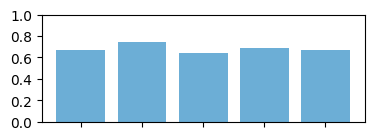

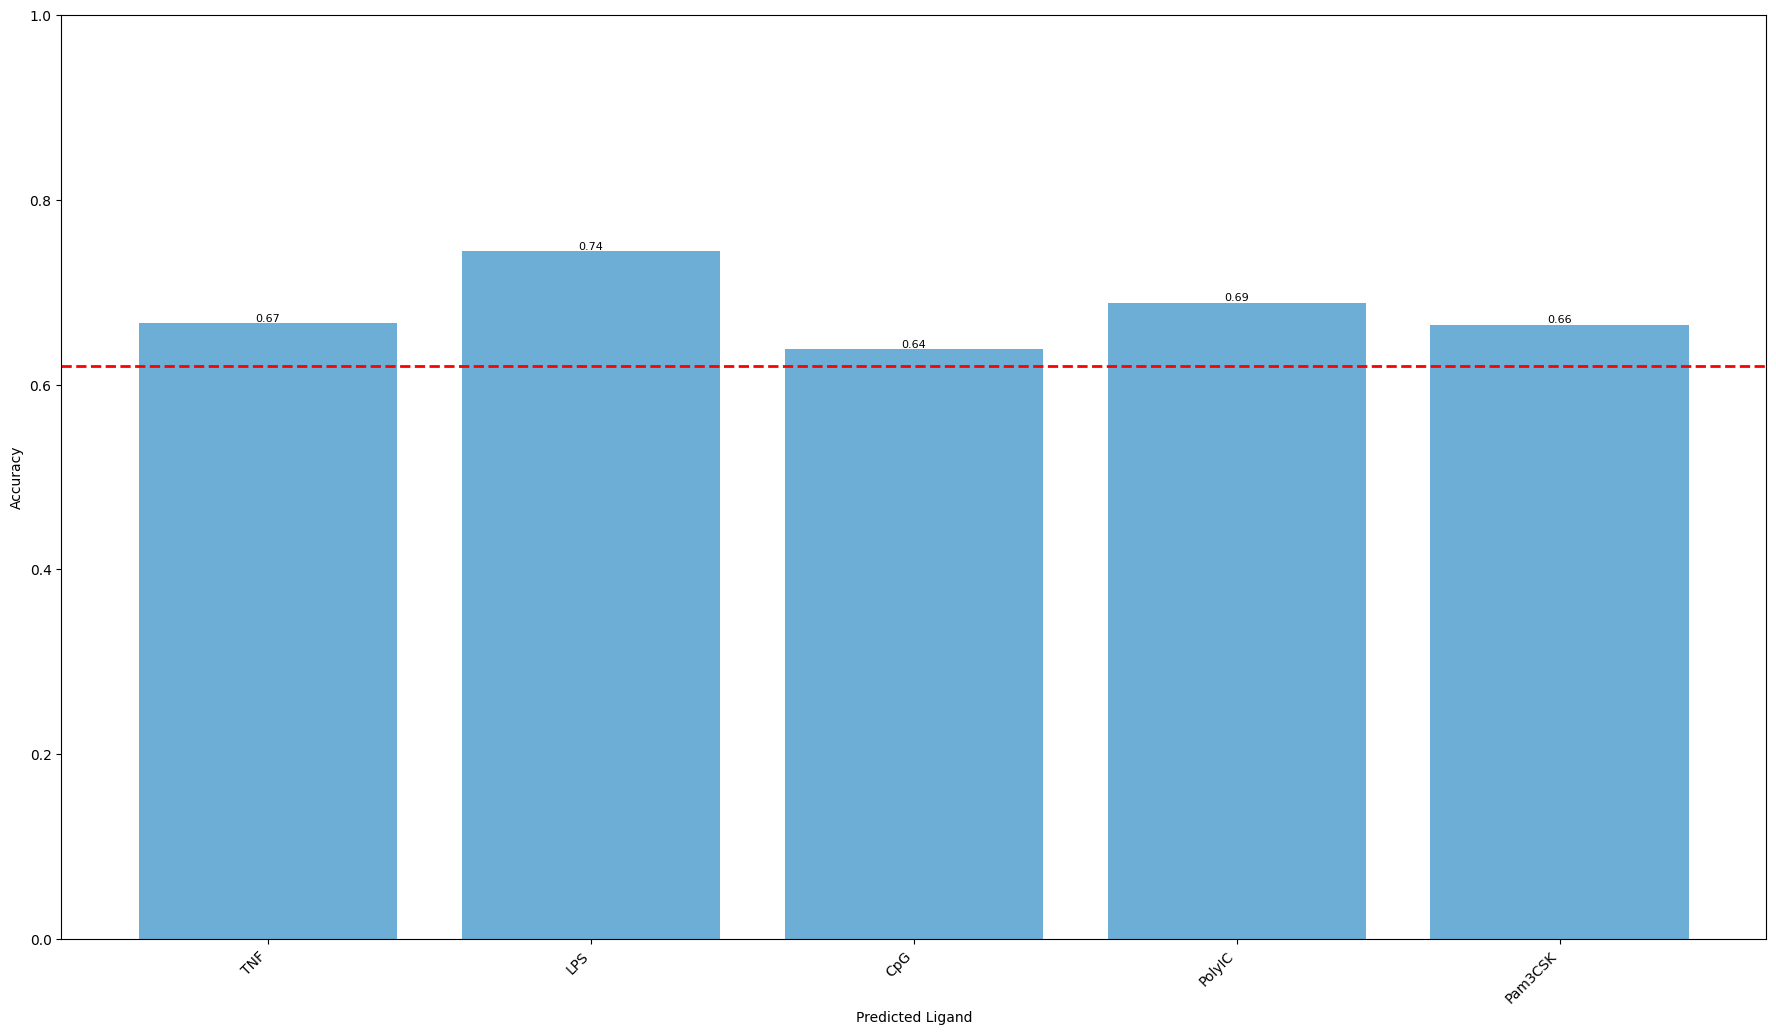

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# define the function
def cal_accuracy(X, y):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    # y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    # cm = confusion_matrix(y_test, y_pred)
        
    # Calculate accuracy
    accuracy = model.score(X_test, y_test)

    return accuracy

# Set to 1 to automatically download PNGs, 0 to not download
auto_download = 0
def save_and_download(filename, download=False, formats=None):
    """Saves the current figure in specified formats and optionally downloads it."""
    if formats is None:
        formats = ['pdf']  # Default format if none specified

    for fmt in formats:
        plt.savefig(f"{filename}.{fmt}", bbox_inches='tight', dpi=300)
        if download and auto_download:
            try:
                from google.colab import files
                files.download(f"{filename}.{fmt}")
            except ImportError:
                print("Not running in Colab environment.  Download skipped.")
                
# Recall Bar Plot
def plot_bar(bar_data, with_labels=False):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(bar_data)
        colors = sns.color_palette("Blues_r", n_colors=1)

        bars = plt.bar(range(num_classes), bar_data, color=colors)
        plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2, label="random classification 0.64")

        # plt.title("accuracy")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_accuracy[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        save_and_download("All_234_comb_accuracy" + "_bar_plot_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(bar_data)), bar_data, color=sns.color_palette("Blues_r", n_colors=1))
        #plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2)
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(bar_data)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        save_and_download("All_234_comb_accuracy" + "_bar_plot_no_labels", download=True, formats=['pdf'])

    plt.show()
    
# Initialize an array to store accuracy values (size 10)
acc_vec_pres_or_not = np.zeros(5)  # Creates an array of zeros with 10 elements
label_accuracy = { 0: 'TNF',  1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'}

#label_mapping = {
#    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK',
#    5: 'TNF_LPS', 6: 'TNF_CpG', 7: 'TNF_PolyIC', 8: 'TNF_Pam3CSK',
#    9: 'LPS_CpG', 10: 'LPS_PolyIC', 11: 'LPS_Pam3CSK', 12: 'CpG_PolyIC',
#    13: 'CpG_Pam3CSK', 14: 'PolyIC_Pam3CSK', 15: 'TNF_LPS_CpG',
#    16: 'TNF_LPS_PolyIC', 17: 'TNF_LPS_Pam3CSK', 18: 'TNF_CpG_PolyIC',
#    19: 'TNF_CpG_Pam3CSK', 20: 'TNF_PolyIC_Pam3CSK', 21: 'LPS_CpG_PolyIC',
#    22: 'LPS_CpG_Pam3CSK', 23: 'LPS_PolyIC_Pam3CSK', 24: 'CpG_PolyIC_Pam3CSK',
#    25: 'TNF_LPS_CpG_PolyIC', 26: 'TNF_LPS_CpG_Pam3CSK',
#    27: 'TNF_LPS_PolyIC_Pam3CSK', 28: 'TNF_CpG_PolyIC_Pam3CSK',
#    29: 'LPS_CpG_PolyIC_Pam3CSK', 30: 'TNF_LPS_CpG_PolyIC_Pam3CSK'
#}

# Load the data
X0 = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y0 = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# Print shapes to verify
print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)

X = X_filtered
y = y_filtered

# case 1
i_case = 1
# Define the label mapping
ligand_label = 'TNF'
label_mapping = {
    0: 'no-TNF', 1: 'TNF'
}
# Define the values to be reassigned to 1
values_to_set_1 = {5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)



# case 2
i_case = 2
# Define the label mapping
ligand_label = 'LPS'
label_mapping = {
    0: 'no-LPS', 1: 'LPS'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 3
i_case = 3
# Define the label mapping
ligand_label = 'CpG'
label_mapping = {
    0: 'no-CpG', 1: 'CpG'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 4
i_case = 4
# Define the label mapping
ligand_label = 'PolyIC'
label_mapping = {
    0: 'no-PolyIC', 1: 'PolyIC'
}
# Define the values to be reassigned to 1
values_to_set_1 = {7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 5
i_case = 5
# Define the label mapping
ligand_label = 'Pam3CSK'
label_mapping = {
    0: 'no-Pam3CSK', 1: 'Pam3CSK'
}
# Define the values to be reassigned to 1
y = y0[mask].reset_index(drop=True)
values_to_set_1 = {8, 11, 13, 14, 17, 19, 20,22,23,24,26,27,28,29}

# Reassign values in y & calculate accuracy
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

print(acc_vec_pres_or_not)

plot_bar(acc_vec_pres_or_not)
plot_bar(acc_vec_pres_or_not,True)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load the data
X = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# # Define the label mapping
# ligand_label = 'TNF'
# label_mapping = {
#     0: 'no-TNF', 1: 'TNF'
# }
# # Define the values to be reassigned to 1
# values_to_set_1 = {0, 5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28,30}


# Define the label mapping
ligand_label = 'PolyIC'
label_mapping = {
    0: 'no-PolyIC', 1: 'PolyIC'
}
# Define the values to be reassigned to 1
values_to_set_1 = {3,  7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29,30}

# # Define the label mapping
# ligand_label = 'LPS'
# label_mapping = {
#     0: 'no-LPS', 1: 'LPS'
# }
# # Define the values to be reassigned to 1
# values_to_set_1 = {1,  5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29,30}

# # Define the label mapping
# ligand_label = 'CpG'
# label_mapping = {
#     0: 'no-CpG', 1: 'CpG'
# }
# # Define the values to be reassigned to 1
# values_to_set_1 = {2, 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29,30}

# # Define the label mapping
# ligand_label = 'Pam3CSK'
# label_mapping = {
#     0: 'no-Pam3CSK', 1: 'Pam3CSK'
# }
# # Define the values to be reassigned to 1
# values_to_set_1 = {4, 8, 11,  13, 14, 17, 19, 20,22,23,24,26,27,28,29,30}

# ## define bacterial PAMPs
# Pam_set = {4, 8, 11, 13, 14, 17, 19, 20, 22, 23, 24, 26, 27, 28, 29, 30}
# CpG_set = {2, 6, 9, 12, 13, 15, 18, 19, 21, 22, 24, 25, 26, 28, 29, 30}
# LPS_set = {1, 5, 9, 10, 11, 15, 16, 17, 21, 22, 23, 25, 26, 27, 29, 30}
# # Compute the union
# values_to_set_1 = Pam_set.union(CpG_set, CpG_set)  # Using union() method
# label_mapping = {
#     0: 'no-bacterial-PAMPs', 1: 'bacterial-PAMPs'
# }

# Reassign values in y
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Define the label mapping
#label_mapping = {
#    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK',
#    5: 'TNF_LPS', 6: 'TNF_CpG', 7: 'TNF_PolyIC', 8: 'TNF_Pam3CSK',
#    9: 'LPS_CpG', 10: 'LPS_PolyIC', 11: 'LPS_Pam3CSK', 12: 'CpG_PolyIC',
#    13: 'CpG_Pam3CSK', 14: 'PolyIC_Pam3CSK', 15: 'TNF_LPS_CpG',
#    16: 'TNF_LPS_PolyIC', 17: 'TNF_LPS_Pam3CSK', 18: 'TNF_CpG_PolyIC',
#    19: 'TNF_CpG_Pam3CSK', 20: 'TNF_PolyIC_Pam3CSK', 21: 'LPS_CpG_PolyIC',
#    22: 'LPS_CpG_Pam3CSK', 23: 'LPS_PolyIC_Pam3CSK', 24: 'CpG_PolyIC_Pam3CSK',
#    25: 'TNF_LPS_CpG_PolyIC', 26: 'TNF_LPS_CpG_Pam3CSK',
#    27: 'TNF_LPS_PolyIC_Pam3CSK', 28: 'TNF_CpG_PolyIC_Pam3CSK',
#    29: 'LPS_CpG_PolyIC_Pam3CSK', 30: 'TNF_LPS_CpG_PolyIC_Pam3CSK'
#}


    
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)

# Define and train the model
model = RandomForestClassifier(random_state=1)
model.fit(X_train, y_train.values.ravel())

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create confusion matrix using only test set predictions
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"Sum of confusion matrix: {np.sum(cm)}") # Verify the size of the confusion matrix

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Condition {label}: {count} samples")

print(f"Total: {sum(counts)} (should be 30,990)")

# Calculate accuracy
accuracy = model.score(X_test, y_test)
acc_vec[i_seed-1] = accuracy
print(f"Model Accuracy: {accuracy:.3f}")

# Sensitivity Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FN = np.sum(cm, axis=1) - TP  # False Negatives

# Compute sensitivity for the full confusion matrix
recall = cm / np.sum(cm, axis=1, keepdims=True)  # Normalize by row sums
recall = np.nan_to_num(recall)  # Replace NaN with 0 (for rows with zero actual instances)
print(recall)
print(np.sum(recall, axis=1))

# Precision Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FP = np.sum(cm, axis=0) - TP  # False Positives

# Compute precision for the full confusion matrix
precision = cm / np.sum(cm, axis=0, keepdims=True)  # Normalize by column sums
precision = np.nan_to_num(precision)  # Replace NaN with 0 (for columns with zero predictions)
print(precision)
print(np.sum(precision, axis=0))

# Compute f-1 score for the full confusion matrix
# Ensure denominator is never zero by adding a small epsilon
epsilon = 1e-10  # A tiny constant to avoid division by zero
f1_score = np.where(
    (precision + recall) == 0,
    0,  # Assign 0 when both precision and recall are zero
    2 * (precision * recall) / (precision + recall + epsilon)  # Avoid exact zero division
)
print(f1_score)
print(np.sum(f1_score, axis=0))

X shape: (14179, 6)
y shape: (14179, 1)
[[1718  693]
 [ 952 1317]]
Sum of confusion matrix: 4680
Condition 0: 7304 samples
Condition 1: 6875 samples
Total: 14179 (should be 30,990)
Model Accuracy: 0.649
[[0.7125674  0.2874326 ]
 [0.41956809 0.58043191]]
[1. 1.]
[[0.64344569 0.34477612]
 [0.35655431 0.65522388]]
[1. 1.]
[[0.67624483 0.31350373]
 [0.38550314 0.61556438]]
[1.06174797 0.92906812]


Original X shape: (14179, 6) Filtered X shape: (8697, 6)
Original y shape: (14179, 1) Filtered y shape: (8697, 1)


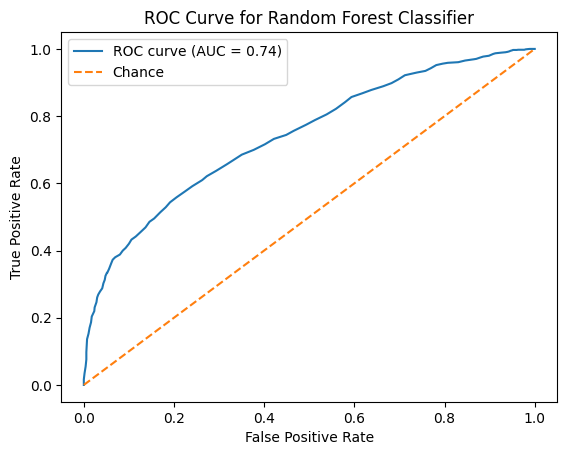

/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4911
dtype: int64
y shape: (8697, 1)


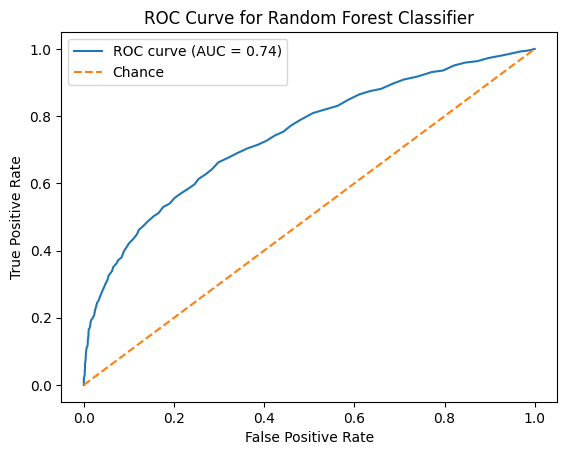

/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    2825
dtype: int64
y shape: (8697, 1)


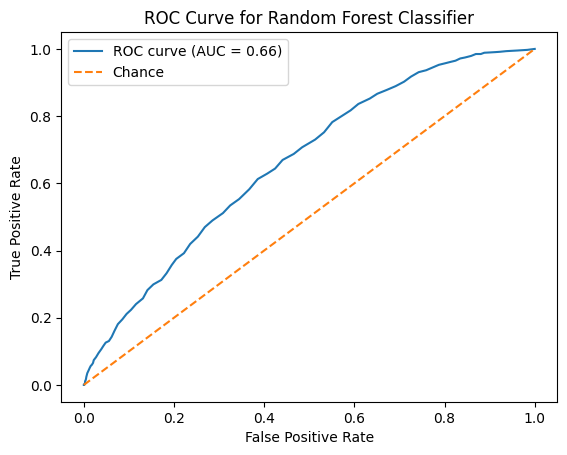

/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    3200
dtype: int64
y shape: (8697, 1)


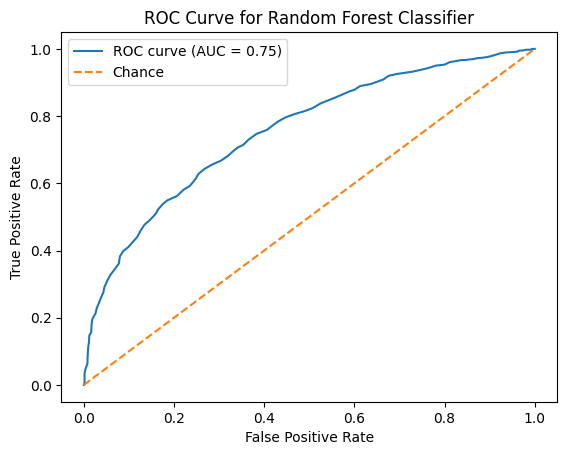

/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4990
dtype: int64
y shape: (8697, 1)


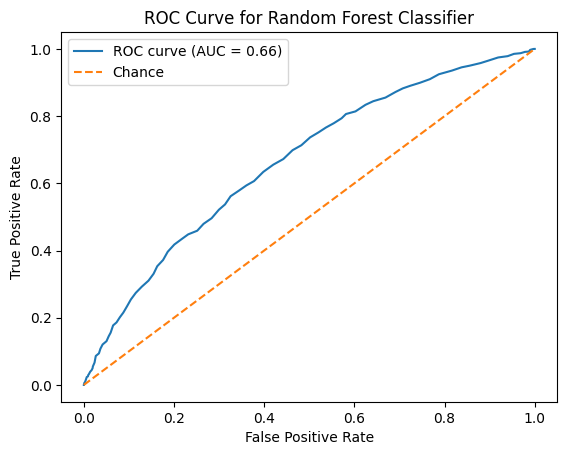

sum of y after reasign val 0    3095
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [4]:
# run to get ROC curve etc 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

# define the function
def cal_ROC_curve(X, y):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    # y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    # cm = confusion_matrix(y_test, y_pred)
    
    # Predict probabilities for the positive class
    y_score = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
        
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Random Forest Classifier')
    plt.legend(loc='best')
    plt.show()

# Recall Bar Plot
def plot_bar(bar_data, with_labels=False):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(bar_data)
        colors = sns.color_palette("Blues_r", n_colors=1)

        bars = plt.bar(range(num_classes), bar_data, color=colors)
        plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2, label="random classification 0.64")

        # plt.title("accuracy")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_accuracy[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        save_and_download("All_234_comb_accuracy" + "_bar_plot_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(bar_data)), bar_data, color=sns.color_palette("Blues_r", n_colors=1))
        #plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2)
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(bar_data)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        save_and_download("All_234_comb_accuracy" + "_bar_plot_no_labels", download=True, formats=['pdf'])

    plt.show()
    
# Initialize an array to store accuracy values (size 10)
acc_vec_pres_or_not = np.zeros(5)  # Creates an array of zeros with 10 elements
label_accuracy = { 0: 'TNF',  1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'}

#label_mapping = {
#    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK',
#    5: 'TNF_LPS', 6: 'TNF_CpG', 7: 'TNF_PolyIC', 8: 'TNF_Pam3CSK',
#    9: 'LPS_CpG', 10: 'LPS_PolyIC', 11: 'LPS_Pam3CSK', 12: 'CpG_PolyIC',
#    13: 'CpG_Pam3CSK', 14: 'PolyIC_Pam3CSK', 15: 'TNF_LPS_CpG',
#    16: 'TNF_LPS_PolyIC', 17: 'TNF_LPS_Pam3CSK', 18: 'TNF_CpG_PolyIC',
#    19: 'TNF_CpG_Pam3CSK', 20: 'TNF_PolyIC_Pam3CSK', 21: 'LPS_CpG_PolyIC',
#    22: 'LPS_CpG_Pam3CSK', 23: 'LPS_PolyIC_Pam3CSK', 24: 'CpG_PolyIC_Pam3CSK',
#    25: 'TNF_LPS_CpG_PolyIC', 26: 'TNF_LPS_CpG_Pam3CSK',
#    27: 'TNF_LPS_PolyIC_Pam3CSK', 28: 'TNF_CpG_PolyIC_Pam3CSK',
#    29: 'LPS_CpG_PolyIC_Pam3CSK', 30: 'TNF_LPS_CpG_PolyIC_Pam3CSK'
#}

# Load the data
X0 = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y0 = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# Print shapes to verify
print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)

X = X_filtered
y = y_filtered

# case 1
i_case = 1
# Define the label mapping
ligand_label = 'TNF'
label_mapping = {
    0: 'no-TNF', 1: 'TNF'
}
# Define the values to be reassigned to 1
values_to_set_1 = {5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
cal_ROC_curve(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)



# case 2
i_case = 2
# Define the label mapping
ligand_label = 'LPS'
label_mapping = {
    0: 'no-LPS', 1: 'LPS'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
cal_ROC_curve(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 3
i_case = 3
# Define the label mapping
ligand_label = 'CpG'
label_mapping = {
    0: 'no-CpG', 1: 'CpG'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
cal_ROC_curve(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 4
i_case = 4
# Define the label mapping
ligand_label = 'PolyIC'
label_mapping = {
    0: 'no-PolyIC', 1: 'PolyIC'
}
# Define the values to be reassigned to 1
values_to_set_1 = {7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
cal_ROC_curve(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 5
i_case = 5
# Define the label mapping
ligand_label = 'Pam3CSK'
label_mapping = {
    0: 'no-Pam3CSK', 1: 'Pam3CSK'
}
# Define the values to be reassigned to 1
y = y0[mask].reset_index(drop=True)
values_to_set_1 = {8, 11, 13, 14, 17, 19, 20,22,23,24,26,27,28,29}

# Reassign values in y & calculate accuracy
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_accuracy(X, y)
cal_ROC_curve(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

#plot_bar(acc_vec_pres_or_not)
#plot_bar(acc_vec_pres_or_not,True)




Original X shape: (14179, 6) Filtered X shape: (8697, 6)
Original y shape: (14179, 1) Filtered y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4911
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    2825
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    3200
dtype: int64
y shape: (8697, 1)


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


sum of y after reasign val 0    4990
dtype: int64
y shape: (8697, 1)
sum of y after reasign val 0    3095
dtype: int64
y shape: (8697, 1)
[0.66138408 0.65722444 0.57445764 0.67645496 0.59521913]


/opt/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


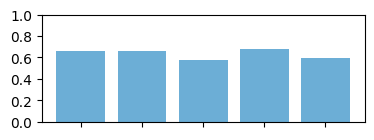

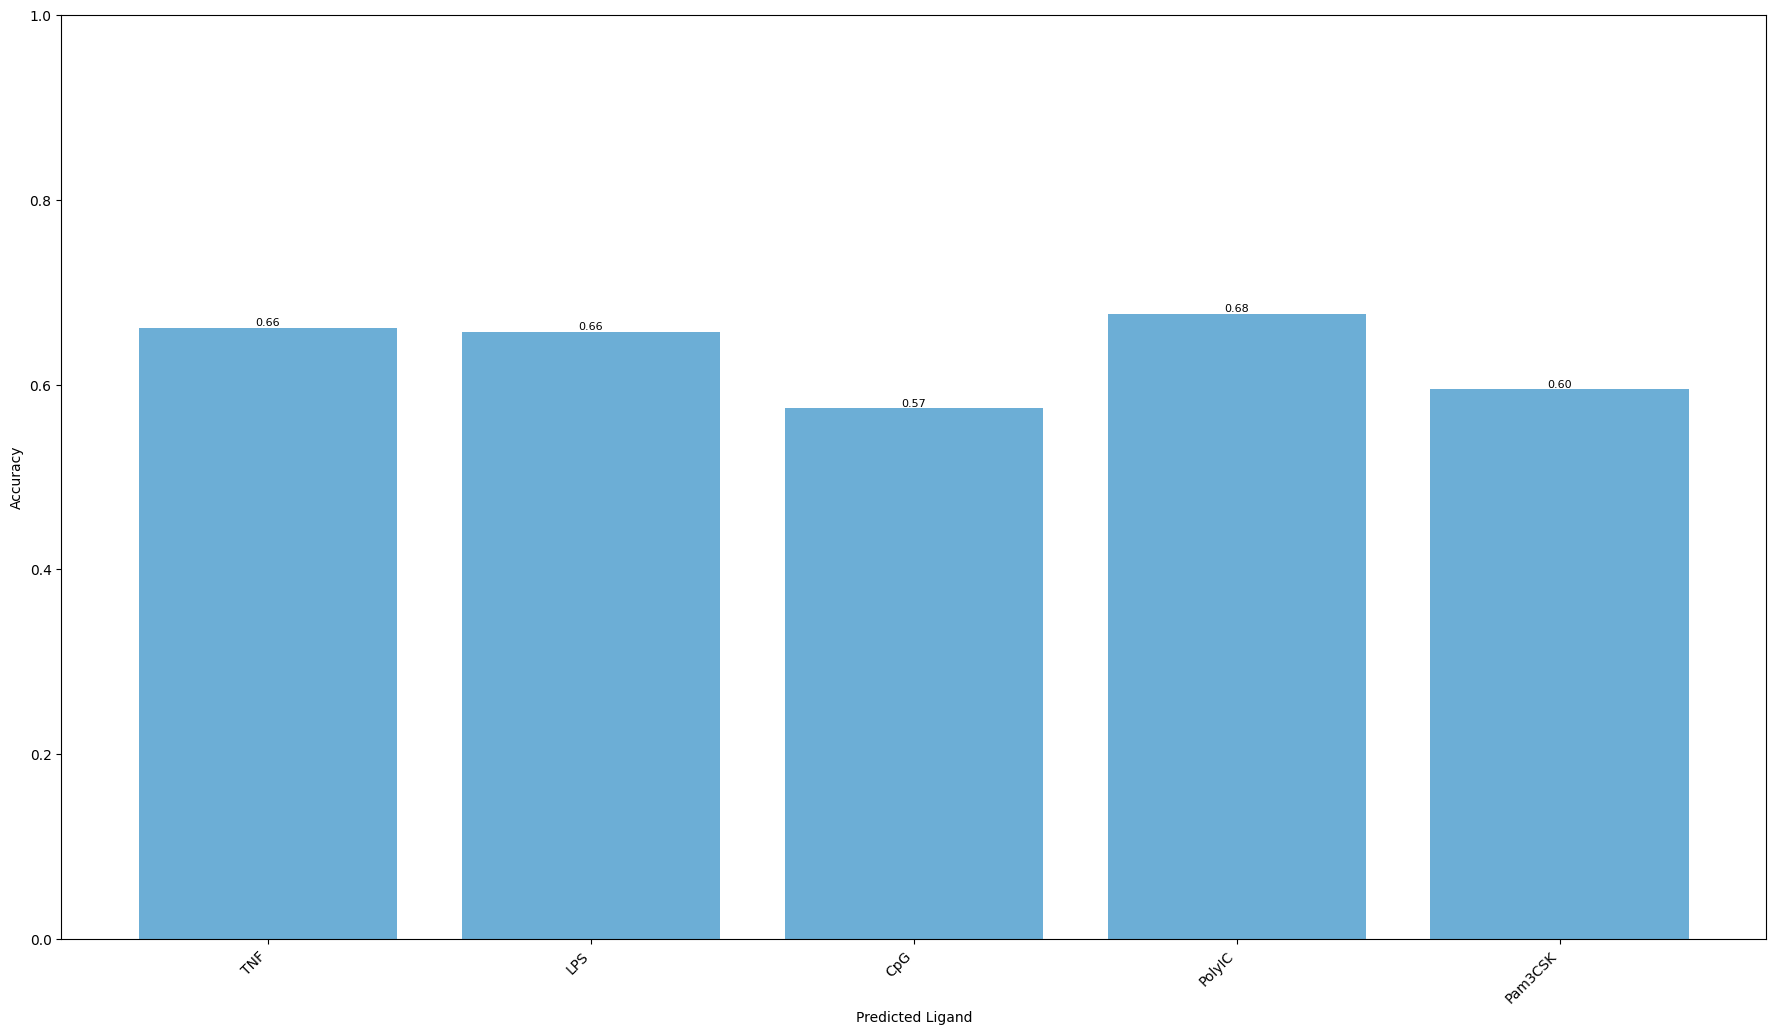

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score


# define the function
def cal_balanced_accuracy(X, y):
         
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)
    
    # Define and train the model
    model = RandomForestClassifier(random_state=1)
    model.fit(X_train, y_train.values.ravel())
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Create confusion matrix using only test set predictions
    # cm = confusion_matrix(y_test, y_pred)
        
    # Calculate accuracy
    accuracy = model.score(X_test, y_test)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)


    return balanced_accuracy

# Recall Bar Plot
def plot_bar(bar_data, with_labels=False):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(bar_data)
        colors = sns.color_palette("Blues_r", n_colors=1)

        bars = plt.bar(range(num_classes), bar_data, color=colors)
        # plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2, label="random classification 0.64")

        # plt.title("accuracy")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_accuracy[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        save_and_download("All_234_comb_accuracy" + "_bar_plot_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(bar_data)), bar_data, color=sns.color_palette("Blues_r", n_colors=1))
        #plt.axhline(y=0.62, color='red', linestyle='--', linewidth=2)
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(bar_data)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        save_and_download("All_234_comb_accuracy" + "_bar_plot_no_labels", download=True, formats=['pdf'])

    plt.show()
    
# Initialize an array to store accuracy values (size 10)
acc_vec_pres_or_not = np.zeros(5)  # Creates an array of zeros with 10 elements
label_accuracy = { 0: 'TNF',  1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'}

#label_mapping = {
#    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK',
#    5: 'TNF_LPS', 6: 'TNF_CpG', 7: 'TNF_PolyIC', 8: 'TNF_Pam3CSK',
#    9: 'LPS_CpG', 10: 'LPS_PolyIC', 11: 'LPS_Pam3CSK', 12: 'CpG_PolyIC',
#    13: 'CpG_Pam3CSK', 14: 'PolyIC_Pam3CSK', 15: 'TNF_LPS_CpG',
#    16: 'TNF_LPS_PolyIC', 17: 'TNF_LPS_Pam3CSK', 18: 'TNF_CpG_PolyIC',
#    19: 'TNF_CpG_Pam3CSK', 20: 'TNF_PolyIC_Pam3CSK', 21: 'LPS_CpG_PolyIC',
#    22: 'LPS_CpG_Pam3CSK', 23: 'LPS_PolyIC_Pam3CSK', 24: 'CpG_PolyIC_Pam3CSK',
#    25: 'TNF_LPS_CpG_PolyIC', 26: 'TNF_LPS_CpG_Pam3CSK',
#    27: 'TNF_LPS_PolyIC_Pam3CSK', 28: 'TNF_CpG_PolyIC_Pam3CSK',
#    29: 'LPS_CpG_PolyIC_Pam3CSK', 30: 'TNF_LPS_CpG_PolyIC_Pam3CSK'
#}

# Load the data
X0 = pd.read_csv('Comb_ligands_exp_conditions_X_codon_.csv', header=None)
y0 = pd.read_csv('Comb_ligands_exp_conditions_y_codon_.csv', header=None)

# remove single, and 5-combinatorial ones
# Define values to be removed
values_to_remove = {0, 1, 2, 3, 4, 30}

# Get mask for rows where y is NOT in values_to_remove
mask = ~y0[0].isin(values_to_remove)

# Apply mask to X and y
X_filtered = X0[mask].reset_index(drop=True)  # Reset index after filtering
y_filtered = y0[mask].reset_index(drop=True)

# Print shapes to verify
print("Original X shape:", X0.shape, "Filtered X shape:", X_filtered.shape)
print("Original y shape:", y0.shape, "Filtered y shape:", y_filtered.shape)

X = X_filtered
y = y_filtered

# case 1
i_case = 1
# Define the label mapping
ligand_label = 'TNF'
label_mapping = {
    0: 'no-TNF', 1: 'TNF'
}
# Define the values to be reassigned to 1
values_to_set_1 = {5, 6, 7, 8, 15, 16, 17, 18, 19,20,25,26,27,28}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_balanced_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)



# case 2
i_case = 2
# Define the label mapping
ligand_label = 'LPS'
label_mapping = {
    0: 'no-LPS', 1: 'LPS'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 5, 9, 10, 11, 15, 16, 17, 21,22,23,25,26,27,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_balanced_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 3
i_case = 3
# Define the label mapping
ligand_label = 'CpG'
label_mapping = {
    0: 'no-CpG', 1: 'CpG'
}
# Define the values to be reassigned to 1
values_to_set_1 = { 6, 9, 12, 13, 15, 18, 19, 21,22,24,25,26,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_balanced_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 4
i_case = 4
# Define the label mapping
ligand_label = 'PolyIC'
label_mapping = {
    0: 'no-PolyIC', 1: 'PolyIC'
}
# Define the values to be reassigned to 1
values_to_set_1 = {7, 10, 12, 14, 16, 18, 20,21,23,24,25,27,28,29}

# Reassign values in y & calculate accuracy
y = y0[mask].reset_index(drop=True)
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_balanced_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

# case 5
i_case = 5
# Define the label mapping
ligand_label = 'Pam3CSK'
label_mapping = {
    0: 'no-Pam3CSK', 1: 'Pam3CSK'
}
# Define the values to be reassigned to 1
y = y0[mask].reset_index(drop=True)
values_to_set_1 = {8, 11, 13, 14, 17, 19, 20,22,23,24,26,27,28,29}

# Reassign values in y & calculate accuracy
y[0] = y[0].apply(lambda val: 1 if val in values_to_set_1 else 0)
acc_vec_pres_or_not[i_case-1] = cal_balanced_accuracy(X, y)
print("sum of y after reasign val",np.sum(y))
print("y shape:", y.shape)

print(acc_vec_pres_or_not)

plot_bar(acc_vec_pres_or_not)
plot_bar(acc_vec_pres_or_not,True)